In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
x = np.array([0, 1, 2, 3, 4, 5], dtype=float)
y = np.array([0, 1, 0, 1, 0, 1], dtype=float)

In [3]:
h = np.diff(x)
n = len(x)

A = np.zeros(n - 2)
B = np.zeros(n - 2)
C = np.zeros(n - 2)
D = np.zeros(n - 2)

for i in range(1, n - 1):
    A[i - 1] = h[i - 1]
    B[i - 1] = 2 * (h[i - 1] + h[i])
    C[i - 1] = h[i]
    D[i - 1] = 6 * ((y[i + 1] - y[i]) / h[i] - (y[i] - y[i - 1]) / h[i - 1])

In [4]:
def thomas(A, B, C, D):
    n = len(D)

    C_prime = np.zeros(n)
    D_prime = np.zeros(n)

    C_prime[0] = C[0] / B[0]
    D_prime[0] = D[0] / B[0]

    for i in range(1, n):
        denom = B[i] - A[i] * C_prime[i - 1]
        C_prime[i] = C[i] / denom if i < n - 1 else 0
        D_prime[i] = (D[i] - A[i] * D_prime[i - 1]) / denom

    M_internal = np.zeros(n)
    M_internal[-1] = D_prime[-1]

    for i in range(n - 2, -1, -1):
        M_internal[i] = D_prime[i] - C_prime[i] * M_internal[i + 1]

    return M_internal

In [5]:
M = np.zeros(n)
M[1:-1] = thomas(A, B, C, D)

In [6]:
def evaluate_spline(x, y, M, x_eval):
    for i in range(len(x) - 1):
        if x[i] <= x_eval <= x[i + 1]:
            h = x[i + 1] - x[i]

            term1 = M[i] * (x[i + 1] - x_eval)**3 / (6 * h)
            term2 = M[i + 1] * (x_eval - x[i])**3 / (6 * h)
            term3 = (y[i] - M[i] * h**2 / 6) * (x[i + 1] - x_eval) / h
            term4 = (y[i + 1] - M[i + 1] * h**2 / 6) * (x_eval - x[i]) / h

            return term1 + term2 + term3 + term4

In [7]:
x_vals = np.linspace(0, 5, 100)
y_vals = np.array([evaluate_spline(x, y, M, xi) for xi in x_vals])

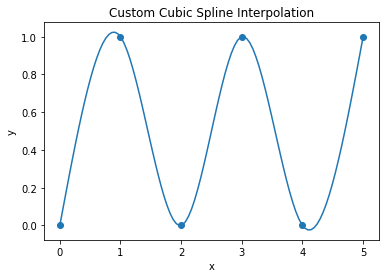

In [8]:
plt.scatter(x, y)
plt.plot(x_vals, y_vals)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Custom Cubic Spline Interpolation")

plt.show()